# Use of Hawkes processes in finance

Author: Federico Baio

### Abstract

This project analyze the microstructure of the Bitcoin (BTC-USD) market by modeling volatility clustering using a temporal Hawkes process. Using hourly log-returns, we isolate extreme price movements and retrive the estimation of the parameters via Maximum Likelihood Estimation (MLE), using gradient-based optimization. The empirical results quantify the reflexive nature of the crypto market, revealing a branching ratio ($\alpha$) of roughly 0.53; which indicate that over half of severe volatility shocks are endogenously driven by internal contagion rather than exogenous news. Furthermore, the estimated decay parameter ($\beta$) indicate a relaxation half-life of approximately 14.5 hours. Beyond the theoretical framework, we make use of the continuous conditional intensity $\lambda(t)$ as quantitative signal. In a trading environment, this signal serves as risk proxy, allowing liquidity providers to defensively scale exposures or asymmetrically widen bid-ask spreads to monetize during periods of extreme market hysteresis.

## Univariate temporal Hawkes process: Mathematical framework

We define a temporal Hawkes process as a particular type of inhomogeneous Poisson point process, originally proposed by Hawkes (1971). For a temporal point process where the event times are $t_i \in [0,T]$ such that $t_i < t_{i+1}$, the right-continuous counting measure $N(A)$ defines the number of events occurring in the time interval $A$. 

A key characteristic of this model is its self-exciting behavior, which leads to situations where the occurrence of one event increases the likelihood of future events. Hawkes and Oakes (1974) provided an alternative representation of a self-exciting process as a Poisson branching process. Thinking of each event as a "parent," an event occurring at time $t_i$ gives birth to offspring according to a stationary process with intensity $g(t-t_i)$ for $t > t_i$. These offspring then generate their own offspring, and so on.

The influence of past events is strictly additive. We define the history of all events up to time $t$ as $\mathcal{H}_t$. The conditional density of the point process, which quantifies the instantaneous rate of events occurring at time $t$, can be expressed as:

$$\lambda(t|\mathcal{H}_t) = \lim_{\Delta t \to 0} \frac{E \left[ N \in [t, t+\Delta t) \mid \mathcal{H}_t \right]}{\Delta t}$$

Equivalently, Hawkes processes can be defined in terms of a conditional intensity function:

$$\lambda(t|\mathcal{H}_t) = \mu + \int_{0}^{t} g(t-u) dN(u) = \mu + \sum_{i: t_i < t} g(t-t_i)$$

Where:
* $\mu$ (Background Rate): A nonnegative function representing exogenous events. For simplicity in financial high-frequency modeling, it often takes a constant form.
* $g(t)$ (Triggering Kernel): A nonnegative function determining the endogenous self-excitation. It dictates how past events decay over time and trigger future events.

### The Exponential kernel and Stationarity

The most widely used parametric form for the triggering kernel is the exponential kernel:

$$g(t) = \alpha\beta \exp(-\beta t)$$

with $\alpha > 0$ and $\beta > 0$. Here, $\alpha$ can be interpreted as the overall strength of the excitation (the jump size in intensity), while $\beta$ controls the temporal decay (the relaxation time of the perturbations). 

To ensure the process does not explode (i.e., the expected total cluster size remains finite), the branching ratio $b$ must be strictly less than 1:

$$b = \int_0^{\infty} g(t) dt = \alpha < 1$$

Under this weak stationarity condition, the expected total cluster size is given by $\frac{1}{1-\alpha}$.

### Maximum Likelihood Estimation (MLE)

It is worth noting that for a temporal Hawkes process with a constant background $\mu$ and an exponential kernel, the log-likelihood function admits a highly efficient closed-form solution:

$$\ell(\Theta) = \sum_{i=1}^{n} \log \lambda( t_i) - \int_{0}^{T} \lambda(t) dt$$

Where the integral resolves to:

$$\int_{0}^{T} \lambda(t) dt = \mu T + \frac{\alpha}{\beta} \sum^{n}_{i=1} \left( 1 - \exp(-\beta (T-t_i)) \right)$$

## Financial use-case: Volatility clustering and Market microstructure

In financial markets, extreme events rarely occur in isolation. As famously noted by Mandelbrot, "large changes tend to be followed by large changes, of either sign, and small changes tend to be followed by small changes." This empirical property is known as volatility clustering. 

The temporal Hawkes process is extremely well-suited to model this phenomenon, because its mathematical architecture directly separates the market activity in two distinct components: exogenous shocks and endogenous contagion.

We can map the theoretical components of the model to market dynamics as follows:

* The Events ($t_i$): In a macroeconomic or trading context, an event can be defined as an extreme price movement (e.g. hourly log-returns exceeding a specific threshold).
* The Background Rate ($\mu$): This represents the exogenous rate of events. In finance, this might captures market activity driven by external factors, such as scheduled macroeconomic data releases (e.g. reports, Federal Reserve announcements) or regular institutional portfolio rebalancing.
* The Self-Exciting Kernel ($g(t-t_i)$): This captures the endogenous contagion, or the market's internal feedback loop. For example, a sudden drop in price triggers algorithmic stop-loss orders and momentum-driven selling. This creates a cascade of subsequent events. 
    * $\alpha$ (Branching Ratio): Represents the "offspring" of the events, i.e. the proportion of market events that are internally triggered by previous events. 
    * $\beta$ (Decay Rate): Represents "decay" of the effect of the events, i.e.the relaxation time. It measures how quickly the market "digests" the initial shock and absorbs the imbalance before returning to its baseline state (the background rate).

By estimating these parameters on historical price data we can continuously calculate the conditional intensity $\lambda(t)$. In a live trading environment, $\lambda(t)$ acts as a proxy for "market temperature". If $\lambda(t)$ spikes, this signal a high-risk contagion regime (does not predict price direction); indeed, it enters a defensive state reducing position sizing or pausing execution algorithms until $\beta$ decays the intensity back to normal levels.

### Install and import the libraries
We start by importing the libraries that we need

In [1]:
# pip3 install numpy matplotlib scipy pandas yfinance
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from scipy.optimize import minimize
from scipy.stats import norm

### Import the dataset

The next step is now to import the dataset thate we want to use. We chose to model and apply a Hawkes process to the dynamics of Bitcoin over the past six years. 

This has been done in order to capture phenomena such as sudden crashes, irrational panic and strong volatility clustering. This context appears to be particularly suitable, as the market dynamics suggest a setting in which endogenous effects may play a significant role. 

The events here are defined as the moments where the log-return exceed a specific threshold, and we use log returns for many reasons. The classic ones are time additivity and simmetry, but in this specific case, since a Hawkes process is a continous time process, and the log-returns represent the continuous capitalization rate of the price; they are the perfect native measure to use in conjunction with continuous-time stochastic models.

Total trading hours: 17147
Number of extreme events detected (> 1.5%): 347


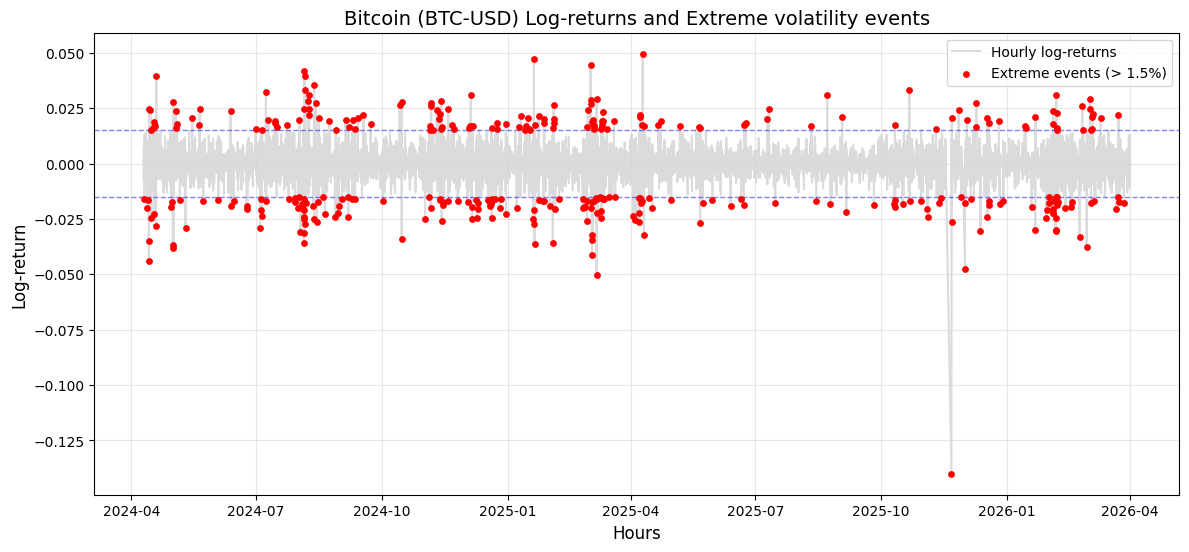

In [2]:
ticker = "BTC-USD" # (Strictly within the last 730 days to avoid Yahoo limits)
df = yf.download(ticker, start="2024-04-10", end="2026-04-01", interval="1h", progress=False)

df['Log_return'] = np.log(df['Close'] / df['Close'].shift(1))
df = df.dropna() # simply remove n/a

# We define an event as a hour where the absolute log-return exceeds 2%
threshold = 0.015
df['Event'] = np.abs(df['Log_return']) > threshold

# Extract event times (in hours) in a continuous numerical format
start_date = df.index.min()
df['Hours_since_start'] = (df.index - start_date).total_seconds() / 3600.0
event_times = df[df['Event']]['Hours_since_start'].values

print(f"Total trading hours: {len(df)}")
print(f"Number of extreme events detected (> {threshold*100}%): {len(event_times)}")

plt.figure(figsize=(14, 6))
plt.plot(df.index, df['Log_return'], label='Hourly log-returns', color='lightgray', alpha=0.8)
event_dates = df[df['Event']].index
event_returns = df[df['Event']]['Log_return']
plt.scatter(event_dates, event_returns, color='red', s=15, label=f'Extreme events (> {threshold*100}%)', zorder=5)
plt.axhline(threshold, color='blue', linestyle='--', linewidth=1, alpha=0.5)
plt.axhline(-threshold, color='blue', linestyle='--', linewidth=1, alpha=0.5)
plt.title('Bitcoin (BTC-USD) Log-returns and Extreme volatility events', fontsize=14)
plt.xlabel('Hours', fontsize=12)
plt.ylabel('Log-return', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### MLE of parameters

In [3]:
def nll_hawkes(par, events, T):
    # par contains mu, alpha and beta
    mu = par[0]
    alpha = par[1]
    beta = par[2]
    N = len(events)
    
    # The first part of the integral is simply integral(mu) -> mu*T
    integral_term = mu * T
    
    # Second part of the integral
    integral_term = integral_term + np.sum(alpha * (1 - np.exp(-beta * (T - events))))
    
    # We evaluate now the first part of the likelihood that is sum(log(lambda(t)))
    sum_log_intensity = 0
    

    for i in range(N):
        t_i = events[i]
        triggering_factor = 0
        if i > 0:
            # All the previous time for that i are simply: events[0:i] 
            t_j_vec = events[0:i]
            # Kernel: alpha * beta * exp(-beta * (t_i - t_j))
            kernel_values = alpha * beta * np.exp(-beta * (t_i - t_j_vec))
            triggering_factor = np.sum(kernel_values)
        
        # we add the mu background intensity in t_i
        lambda_t_i = mu + triggering_factor
        sum_log_intensity = sum_log_intensity + np.log(lambda_t_i)
        
    Neg_LL = integral_term - sum_log_intensity
    return Neg_LL


T = df['Hours_since_start'].max()
initial_guess = [0.01, 0.5, 0.1]
bnds = [(1e-5, None), (1e-5, 0.999), (1e-5, None)]
result = minimize(
    nll_hawkes, 
    initial_guess, 
    args=(event_times, T), 
    method='L-BFGS-B',
    bounds=bnds
)

mu_opt, alpha_opt, beta_opt = result.x
print("\nEstimated parameters")
print(f"Background rate (mu):    {mu_opt:.5f} eventi/hour")
print(f"Branching ratio (alpha): {alpha_opt:.5f} (endogeneity of bitcoin market)")
print(f"Decay rate (beta):       {beta_opt:.5f} (decay to normal rate in the market)")
print(f"Optimization succesful: {result.success}")


Estimated parameters
Background rate (mu):    0.00937 eventi/hour
Branching ratio (alpha): 0.53266 (endogeneity of bitcoin market)
Decay rate (beta):       0.04748 (decay to normal rate in the market)
Optimization succesful: True


### Density plot vs real market events

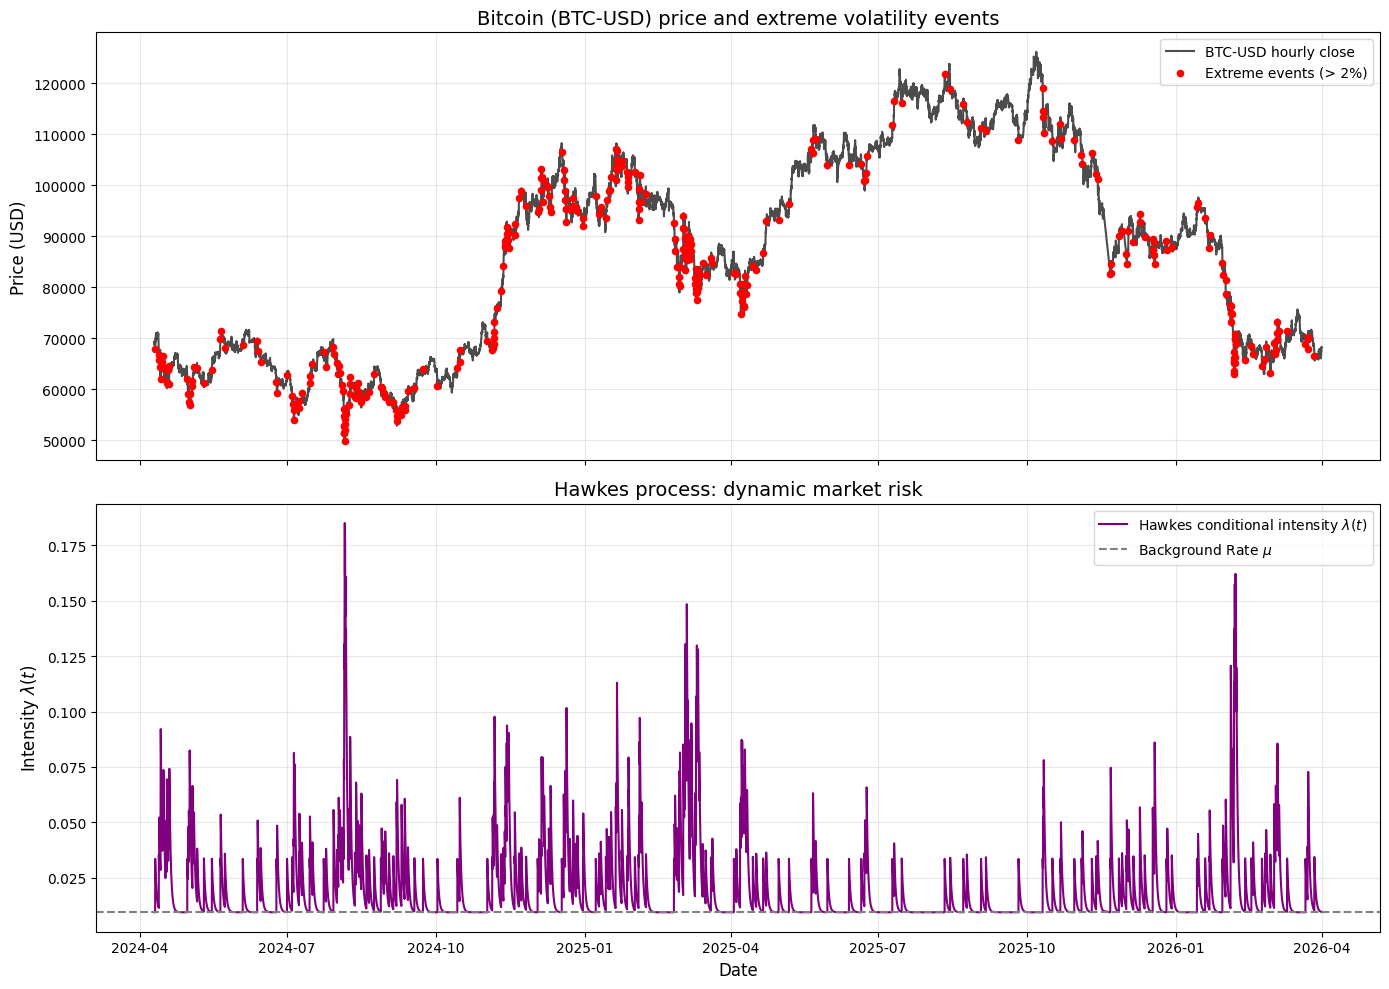

In [4]:
t_grid = df['Hours_since_start'].values
lambda_t = np.zeros(len(t_grid))
for idx, t in enumerate(t_grid):
    past_events = event_times[event_times < t]
    intensity = mu_opt + np.sum(alpha_opt * beta_opt * np.exp(-beta_opt * (t - past_events)))
    lambda_t[idx] = intensity

df['Hawkes intensity'] = lambda_t
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)
ax1.plot(df.index, df['Close'], color='black', alpha=0.7, label='BTC-USD hourly close')
ax1.scatter(df[df['Event']].index, df[df['Event']]['Close'], color='red', s=20, label='Extreme events (> 2%)', zorder=5)
ax1.set_title('Bitcoin (BTC-USD) price and extreme volatility events', fontsize=14)
ax1.set_ylabel('Price (USD)', fontsize=12)
ax1.legend()
ax1.grid(True, alpha=0.3)
ax2.plot(df.index, df['Hawkes intensity'], color='purple', linewidth=1.5, label=r'Hawkes conditional intensity $\lambda(t)$')
ax2.axhline(mu_opt, color='gray', linestyle='--', label=r'Background Rate $\mu$')
ax2.set_title('Hawkes process: dynamic market risk', fontsize=14)
ax2.set_xlabel('Date', fontsize=12)
ax2.set_ylabel(r'Intensity $\lambda(t)$', fontsize=12)
ax2.legend()
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Empirical results and Market insights

The estimated parameters using MLE translate the Hawkes process into market insights:

* Exogenous shocks ($\mu = 0.00937$): The background rate indicates that spontaneous, extreme volatility events; the ones driven purely by external news, occur at a baseline rate of roughly 0.01 times per hour (approximately one shock every 4.4 days). This is visually represented by the dashed gray baseline in the lower plot.
* Market endogeneity ($\alpha = 0.53266$): This is the core metric of market selfexcitation. An $\alpha$ of approximately 0.53 reveals that over 53% of extreme price movements in the Bitcoin market are internally generated. Connecting this value to the mathematical definition of $\alpha$, we can say that in this market every extreme price movement directly triggers 0.53 following extreme events. This satisfies the stationarity condition ($\alpha < 1$) while confirming a highly self-exciting market regime.
* Relaxation time ($\beta = 0.04748$): The decay parameter measures the market's "memory." We can calculate the half-life of a volatility shock as $\ln(2) / \beta \approx 14.6$ hours. When an extreme event happens, it takes roughly 14 to 15 hours for the "market hysteria" to digest it and for the risk intensity to drop by half.

### Visualizing the Signal & Dynamic Risk Management
As demonstrated in the plot above, the conditional intensity $\lambda(t)$ acts as a proxy for market endogenous effects. During periods of market stress (e.g. the dense clusters of extreme returns), the intensity increases, accurately mapping the contagion effect. 

In a quantitative trading framework, this model is not used for price forecasting. Instead, by continuously tracking $\lambda(t)$, a trading system can systematically detect when the market enters a "self-exciting moment". The algorithm can immediately scale down position sizes or stop execution algorithms for the 14-15 hour window following a shock until the baseline rate $\mu$ is restored. 

Beyond risk mitigation, this framework could also set profitable market-making strategies. During periods of high endogenous intensity (when $\lambda(t)$ spikes), the probability of adverse selection increases dramatically. In this situations, a liquidity provider might want to widen the bid-ask spread of its limit orders, effectively monetizing on the market's hysteria.